# Chapter 10 - Gaussian Mixture Model - Exercises

### Nguyễn Phúc Minh Châu - 22302421

## Q1. Cluster the Wine dataset using GMM into 3 clusters.

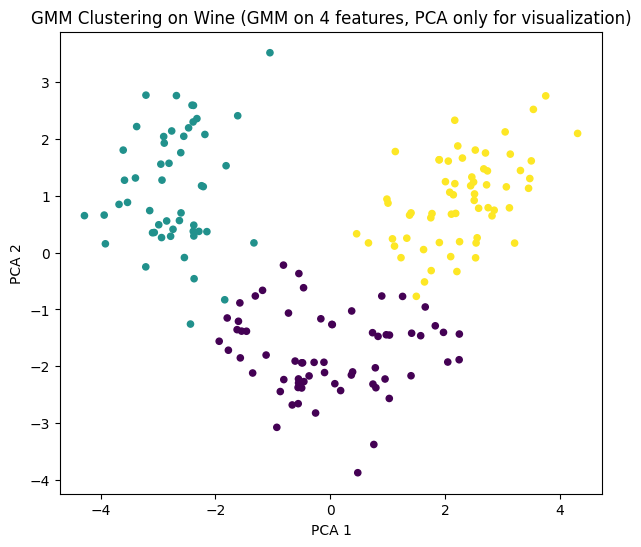

In [ ]:
# Cluster the Wine dataset using GMM into 3 clusters
import numpy as np
import matplotlib.pyplot as plt
from sklearn.mixture import GaussianMixture
from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# 1. Tải dữ liệu Iris
wine = load_wine()
X = wine.data        # dùng cả 4 thuộc tính

# 2. Chuẩn hóa
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 3. Huấn luyện GMM trên dữ liệu 4 chiều
gmm = GaussianMixture(n_components=3, random_state=42)
gmm.fit(X_scaled)
labels = gmm.predict(X_scaled)

# 4. PCA chỉ để giảm còn 2D phục vụ vẽ hình
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# 5. Vẽ scatter trên không gian PCA nhưng nhãn lấy từ GMM 4D
plt.figure(figsize=(7, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels, s=20)
plt.title("GMM Clustering on Wine (GMM on 4 features, PCA only for visualization)")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.show()

In [ ]:
#Show the actual number of Wine types in the dataset
print(f"Actual number of Wine types: {len(np.unique(wine.target))}")

Actual number of Wine types: 3


## Q2. Choose k using BIC

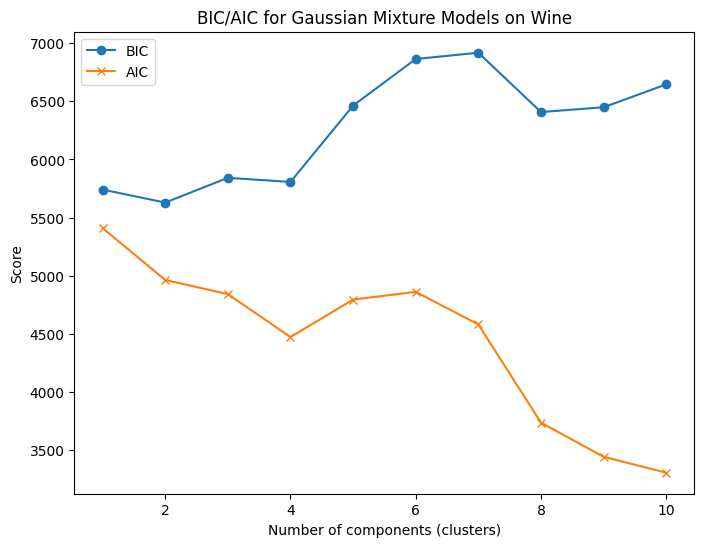

Best number of clusters by BIC: 2
Best number of clusters by AIC: 10


In [ ]:
# Using the Wine dataset, draw BIC curve with k from 1 to 10. Choose the best k.
import numpy as np
import matplotlib.pyplot as plt
from sklearn.mixture import GaussianMixture
from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler

# 1. Tải dữ liệu Iris
wine = load_wine()
X = wine.data        # dùng cả 4 thuộc tính

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

n_components_range = range(1, 11)

bics = []
aics = []

for k in n_components_range:
    gmm = GaussianMixture(n_components=k, random_state=42)
    gmm.fit(X_scaled)
    bics.append(gmm.bic(X_scaled))
    aics.append(gmm.aic(X_scaled))

plt.figure(figsize=(8, 6))
plt.plot(n_components_range, bics, marker='o', label='BIC')
plt.plot(n_components_range, aics, marker='x', label='AIC')
plt.xlabel("Number of components (clusters)")
plt.ylabel("Score")
plt.title("BIC/AIC for Gaussian Mixture Models on Wine")
plt.legend()
plt.show()

best_k_bic = n_components_range[np.argmin(bics)]
best_k_aic = n_components_range[np.argmin(aics)]

print("Best number of clusters by BIC:", best_k_bic)
print("Best number of clusters by AIC:", best_k_aic)


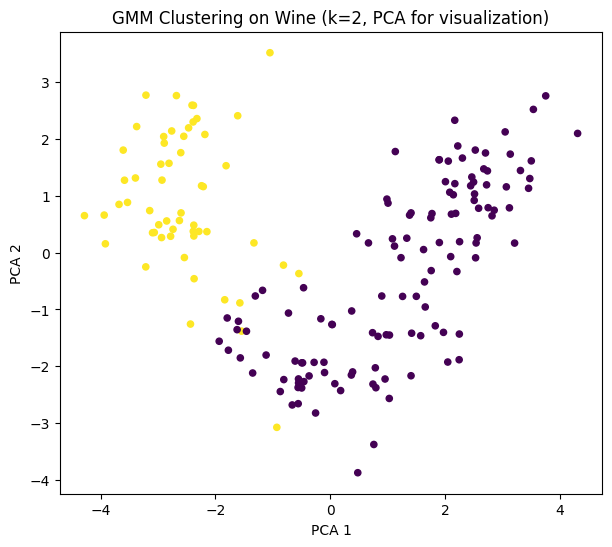

In [ ]:
# Using the best k, cluster the Wine dataset using GMM into k clusters.
import numpy as np
import matplotlib.pyplot as plt
from sklearn.mixture import GaussianMixture
from sklearn.decomposition import PCA

# Assuming X_scaled is already available from previous cells
# Assuming best_k_bic is already available from previous cells (value 2)

# 1. Huấn luyện GMM với best_k_bic
gmm_best_k = GaussianMixture(n_components=best_k_bic, random_state=42)
gmm_best_k.fit(X_scaled)
labels_best_k = gmm_best_k.predict(X_scaled)

# 2. PCA chỉ để giảm còn 2D phục vụ vẽ hình (reuse X_pca if available, otherwise recompute)
# For consistency, let's ensure PCA is done on X_scaled just like in the first cell
pca = PCA(n_components=2)
X_pca_best_k = pca.fit_transform(X_scaled)

# 3. Vẽ scatter trên không gian PCA nhưng nhãn lấy từ GMM
plt.figure(figsize=(7, 6))
plt.scatter(X_pca_best_k[:, 0], X_pca_best_k[:, 1], c=labels_best_k, s=20)
plt.title(f"GMM Clustering on Wine (k={best_k_bic}, PCA for visualization)")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.show()

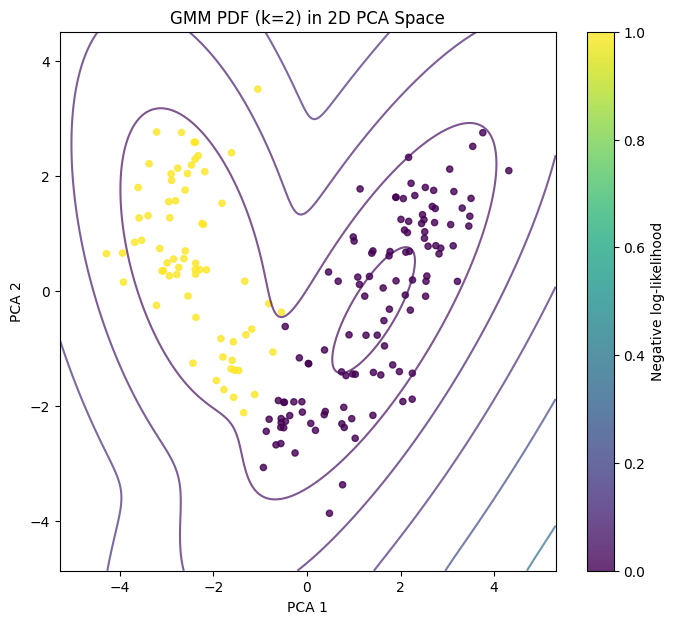

In [ ]:
# Plot the PDF of GMM in the 2D space
import numpy as np
import matplotlib.pyplot as plt

# Assuming gmm_best_k (fitted GMM with best_k_bic) and X_pca_best_k (PCA transformed data) are available

def plot_gmm_pdf(gmm, X_pca, title="GMM PDF in 2D PCA Space"):
    # Create a meshgrid for plotting the PDF
    x_min, x_max = X_pca[:, 0].min() - 1, X_pca[:, 0].max() + 1
    y_min, y_max = X_pca[:, 1].min() - 1, X_pca[:, 1].max() + 1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                           np.linspace(y_min, y_max, 200))

    # Evaluate the GMM's log-likelihood on the meshgrid points
    # We need to transform the meshgrid points back to the original feature space
    # for the GMM to score them, or use a GMM fitted directly on X_pca.
    # Since gmm_best_k was fitted on X_scaled, we need to apply PCA inverse transform
    # to the meshgrid to estimate the density, or, more simply, we can
    # fit a new GMM on the X_pca for visualization purposes.
    # For this task, we will fit a new GMM directly on X_pca for clearer visualization of the 2D PDF.

    # Re-fit GMM on the 2D PCA data for accurate 2D PDF visualization
    gmm_2d = GaussianMixture(n_components=gmm.n_components, random_state=42)
    gmm_2d.fit(X_pca)

    Z = -gmm_2d.score_samples(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.figure(figsize=(8, 7))
    plt.contour(xx, yy, Z, levels=np.logspace(0, 2, 10), cmap='viridis', alpha=0.7)
    plt.scatter(X_pca[:, 0], X_pca[:, 1], c=gmm_2d.predict(X_pca), s=20, alpha=0.8)
    plt.xlabel("PCA 1")
    plt.ylabel("PCA 2")
    plt.title(title)
    plt.colorbar(label='Negative log-likelihood')
    plt.show()

# Plot the PDF using the gmm_best_k (to get the number of components) and X_pca_best_k
plot_gmm_pdf(gmm_best_k, X_pca_best_k, title=f"GMM PDF (k={gmm_best_k.n_components}) in 2D PCA Space")

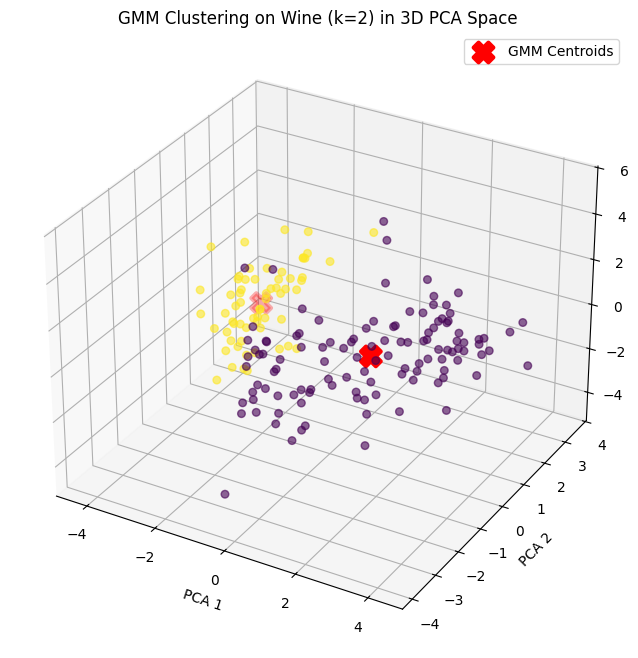

In [ ]:
# Plot the PDF of GMM in the 3D space
import numpy as np
import matplotlib.pyplot as plt
from sklearn.mixture import GaussianMixture
from sklearn.decomposition import PCA
from mpl_toolkits.mplot3d import Axes3D

# Assuming X_scaled is available from previous cells
# Assuming best_k_bic is available (value 2 from previous BIC analysis)

# 1. Perform PCA to reduce X_scaled to 3 components for 3D visualization
pca_3d = PCA(n_components=3)
X_pca_3d = pca_3d.fit_transform(X_scaled)

# 2. Fit GMM on the 3D PCA data
# We use the 'best_k_bic' (number of components identified by BIC) for consistency.
gmm_3d = GaussianMixture(n_components=best_k_bic, random_state=42)
gmm_3d.fit(X_pca_3d)
labels_3d = gmm_3d.predict(X_pca_3d)

# 3. Plot the 3D scatter plot
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Scatter plot of data points, colored by GMM labels
ax.scatter(X_pca_3d[:, 0], X_pca_3d[:, 1], X_pca_3d[:, 2],
           c=labels_3d, s=30, cmap='viridis', alpha=0.6)

# Plot GMM component centroids
# The means are extracted from the GMM fitted on the 3D PCA data
centroids_3d = gmm_3d.means_
ax.scatter(centroids_3d[:, 0], centroids_3d[:, 1], centroids_3d[:, 2],
           marker='X', s=200, linewidths=3, color='red', label='GMM Centroids', zorder=10)

ax.set_xlabel("PCA 1")
ax.set_ylabel("PCA 2")
ax.set_zlabel("PCA 3")
ax.set_title(f"GMM Clustering on Wine (k={best_k_bic}) in 3D PCA Space")
ax.legend()
plt.show()